# Model diagnostics for perpetual-funding signals

This analysis reads only current, complete canonical prediction catalog rows. A row retains its
training, prediction, fold, and checkpoint identity. IC, AUC, and loss diagnose models; they do
not select the trading configuration. Selection occurs after validation backtests and uses Sharpe.

**Learning objectives**

- audit the complete model and checkpoint population through the prediction catalog;
- compare diagnostic metrics without using them as the strategy selection rule; and
- interpret causal evidence separately from predictive performance.

**Book reference:** Chapters 11 to 19, model comparison and diagnostics.

**Prerequisites:** complete canonical outputs from the model execution notebooks and the causal
notebook.

In [1]:
import os

import plotly.express as px
import polars as pl
from IPython.display import Markdown

from case_studies.crypto_perps_funding.research_workflow import (
    OFFICIAL_POPULATION,
    open_study,
    plan_official_models,
)
from case_studies.research import CausalResult, OfficialPopulation
from utils.style import COLORS, ml4t_palette, show_plotly_with_alt

In [2]:
EXECUTION_TIER = "canonical"
WORKSPACE = os.environ.get("ML4T_OUTPUT_DIR", "")

## Complete predictive catalog

In [3]:
study = open_study(execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)
catalog = study.predictions.table(include_preview=EXECUTION_TIER == "preview").filter(
    (pl.col("identity_status") == "current")
    & (pl.col("execution_tier") == EXECUTION_TIER)
    & (pl.col("split") == "validation")
    & pl.col("complete")
)
if catalog.is_empty() or catalog["prediction_hash"].n_unique() != catalog.height:
    raise RuntimeError("the canonical model catalog is empty or has duplicate identities")

Canonical analysis also reconstructs the complete request population. Exact hash equality makes a
missing, extra, or differently resolved checkpoint a blocking error before diagnostics begin.

In [4]:
if EXECUTION_TIER == "canonical":
    population = OfficialPopulation.one(study, name=OFFICIAL_POPULATION)
    population.require_complete()
    declared_hashes = set(plan_official_models(study).expected_prediction_hashes)
    frozen_hashes = set(population.members)
    if frozen_hashes != declared_hashes:
        raise RuntimeError("the frozen model population differs from the declared requests")
    if set(catalog["prediction_hash"]) != frozen_hashes:
        raise RuntimeError("the canonical model catalog differs from the declared population")

In [5]:
catalog.select(
    "family",
    "label",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "training_hash",
    "prediction_hash",
    "ic_mean",
    "auc_roc",
    "log_loss",
).sort("label", "family", "config_name", "checkpoint_value")

family,label,config_name,checkpoint_kind,checkpoint_value,training_hash,prediction_hash,ic_mean,auc_roc,log_loss
str,str,str,str,i64,str,str,f64,f64,f64
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",50,"""5adbe89dca03""","""5ee9323b90a3""",0.018362,0.507932,0.701814
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",100,"""5adbe89dca03""","""edbc302e21bb""",0.017517,0.508706,0.708047
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",150,"""5adbe89dca03""","""46bbc0407015""",0.017338,0.507839,0.714362
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",200,"""5adbe89dca03""","""bac9ef356de4""",0.017905,0.509035,0.720253
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",250,"""5adbe89dca03""","""c350b988b181""",0.017182,0.509161,0.725508
…,…,…,…,…,…,…,…,…,…
"""tabular_dl""","""fwd_ret_8h""","""tabm_s""","""epoch""",100,"""b3a627bdc0b5""","""bdd596f5a37f""",-0.002668,null,null
"""tabular_dl""","""fwd_ret_8h""","""tabm_s""","""epoch""",125,"""b3a627bdc0b5""","""6f078b8199b3""",-0.002068,null,null
"""tabular_dl""","""fwd_ret_8h""","""tabm_s""","""epoch""",150,"""b3a627bdc0b5""","""55e22f9a8288""",-0.003744,null,null


## Diagnostic summaries

These tables describe the registered validation predictions without collapsing checkpoint
identity or intersecting away missing keys. Any incomplete row was rejected before this analysis.

In [6]:
diagnostics = catalog.select(
    "label",
    "family",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "training_hash",
    "prediction_hash",
    "n_folds",
    "ic_mean",
    "ic_std",
    "auc_roc",
    "log_loss",
).sort("label", "family", "config_name", "checkpoint_value")
diagnostics

label,family,config_name,checkpoint_kind,checkpoint_value,training_hash,prediction_hash,n_folds,ic_mean,ic_std,auc_roc,log_loss
str,str,str,str,i64,str,str,f64,f64,f64,f64,f64
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",50,"""5adbe89dca03""","""5ee9323b90a3""",2.0,0.018362,0.001792,0.507932,0.701814
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",100,"""5adbe89dca03""","""edbc302e21bb""",2.0,0.017517,0.01027,0.508706,0.708047
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",150,"""5adbe89dca03""","""46bbc0407015""",2.0,0.017338,0.006663,0.507839,0.714362
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",200,"""5adbe89dca03""","""bac9ef356de4""",2.0,0.017905,0.007449,0.509035,0.720253
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",250,"""5adbe89dca03""","""c350b988b181""",2.0,0.017182,0.006872,0.509161,0.725508
…,…,…,…,…,…,…,…,…,…,…,…
"""fwd_ret_8h""","""tabular_dl""","""tabm_s""","""epoch""",100,"""b3a627bdc0b5""","""bdd596f5a37f""",2.0,-0.002668,0.000023,null,null
"""fwd_ret_8h""","""tabular_dl""","""tabm_s""","""epoch""",125,"""b3a627bdc0b5""","""6f078b8199b3""",2.0,-0.002068,0.003432,null,null
"""fwd_ret_8h""","""tabular_dl""","""tabm_s""","""epoch""",150,"""b3a627bdc0b5""","""55e22f9a8288""",2.0,-0.003744,0.00188,null,null


The distribution below retains every checkpoint. A family with more configured checkpoints is
therefore shown with more points rather than receiving extra weight in a collapsed ranking.

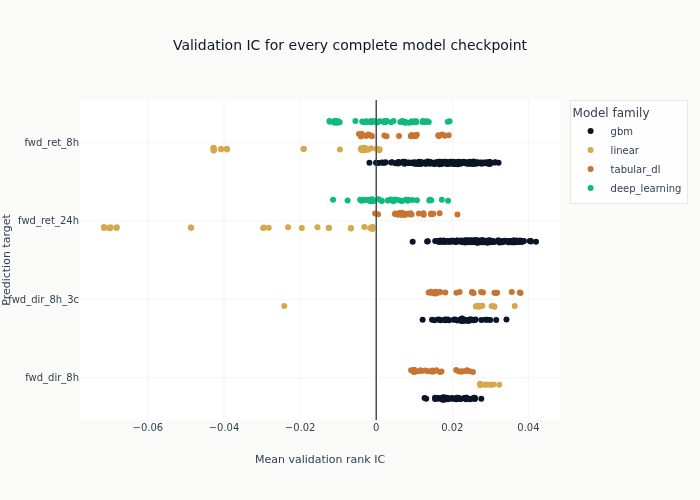

In [7]:
ic_points = catalog.filter(pl.col("ic_mean").is_not_null()).sort(
    "label", "family", "config_name", "checkpoint_value"
)
fig = px.strip(
    ic_points,
    x="ic_mean",
    y="label",
    color="family",
    hover_data=["config_name", "checkpoint_kind", "checkpoint_value"],
    title="Validation IC for every complete model checkpoint",
    labels={"ic_mean": "Mean validation rank IC", "label": "Prediction target"},
    color_discrete_sequence=ml4t_palette(5, categorical=True),
)
fig.add_vline(x=0, line_width=1, line_color=COLORS["neutral"])
fig.update_layout(legend_title_text="Model family")
show_plotly_with_alt(
    fig,
    "Horizontal strip plot with one point per complete model checkpoint, grouped by prediction "
    "target and colored by model family. A vertical zero line separates positive and negative "
    "validation rank correlations.",
)

## Separate causal result

The DML estimand is not placed in the predictive catalog. A reader-facing label selection must
resolve to exactly one current canonical causal identity.

In [8]:
causal = CausalResult.one(study, label="fwd_ret_8h", execution_tier=EXECUTION_TIER)
if not causal.complete:
    raise RuntimeError("causal result is incomplete")
causal_summary = pl.DataFrame(
    {
        "causal_hash": [causal.hash],
        "n_obs": [causal.metrics["n_obs"]],
        "effect": [causal.metrics["dml_effect"]],
        "hac_standard_error": [causal.metrics["dml_se_hac"]],
        "refutation_p": [causal.metrics["refutation_p"]],
    }
)
causal_summary

causal_hash,n_obs,effect,hac_standard_error,refutation_p
str,i64,f64,f64,f64
"""828ab65131b1""",54314,0.001032,0.000971,0.0


In [9]:
# refutation_p is nullable by contract (utils/causal.py:1111), so it is reported as absent
# rather than formatted. A run whose refutation did not produce an empirical p-value is a
# weaker result, and saying so is more useful than omitting the sentence or failing to render.
_refutation = causal.metrics["refutation_p"]
_refutation_text = (
    f"The temporal refutation p-value is **{_refutation:.3f}**."
    if _refutation is not None
    else "No temporal refutation p-value was registered for this estimate."
)
Markdown(
    f"The registered DML estimate is **{causal.metrics['dml_effect']:+.4g}** with "
    f"a HAC standard error of **{causal.metrics['dml_se_hac']:.4g}**. {_refutation_text} "
    "This result describes the declared causal estimand and does not rank predictive models "
    "or trading strategies."
)

The registered DML estimate is **+0.001032** with a HAC standard error of **0.0009709**. The temporal refutation p-value is **0.000**. This result describes the declared causal estimand and does not rank predictive models or trading strategies.

## Key takeaways and limitations

- Catalog completeness is checked against the declared canonical checkpoint population before any
  diagnostic is interpreted.
- IC, AUC, and loss describe predictions. Validation backtest Sharpe selects the trading
  configuration later in the pipeline.
- Model comparisons remain conditional on the finalized features, labels, universe, and validation
  period. The causal estimate also depends on its declared observed-confounder assumptions.